## Homework 02-Regression

### Preparation

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
df.count()

model_year             10000
origin                 10000
fuel_type              10000
drivetrain             10000
num_doors              10000
engine_displacement    10000
num_cylinders          10000
horsepower              9123
vehicle_weight         10000
acceleration            9736
fuel_efficiency_mpg    10000
dtype: int64

In [5]:
df.isna().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

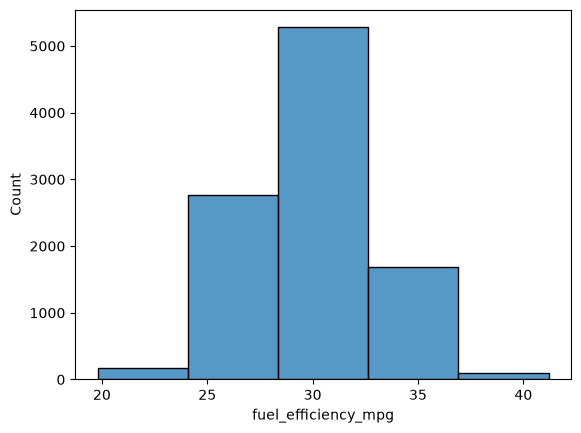

In [7]:
sb.histplot(df.fuel_efficiency_mpg,bins=5)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

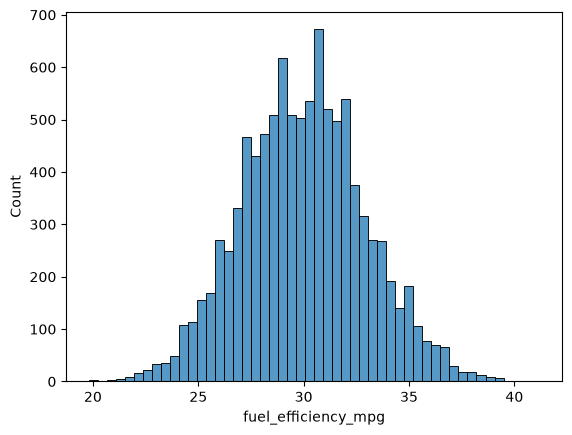

In [8]:
sb.histplot(df.fuel_efficiency_mpg,bins=50)

In [9]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


#### Question 1
There's one column with missing values. What is it?

In [10]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

#### Question 2
What's the median (50% percentile) for variable 'horsepower'?

In [11]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


#### Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

In [50]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [51]:
df_train=df_train.reset_index(drop=True)
df_train=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2240,265.0,3990,2004,30.4
1,2390,259.0,4770,2019,32.8
2,2360,265.0,4320,2018,27.8
3,2430,279.0,4430,2008,28.6
4,2220,249.0,4030,1999,31.1


In [52]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
y_train

array([30.4, 32.8, 27.8, ..., 30.6, 31. , 30.8], shape=(2000,))

In [53]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [54]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [126]:
def rmse(actual_target, predicted_target):
    error = actual_target - predicted_target
    se = error ** 2
    mse = se.mean()
    return round(np.sqrt(mse),4)

In [117]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,2320,246.0,4100,2014
1,2230,252.0,4250,1998
2,2700,276.0,4490,2008
3,2220,269.0,4060,2004
4,2370,NaN,4690,1979


In [118]:
df_train.isna().sum()

engine_displacement      0
horsepower             545
vehicle_weight           0
model_year               0
dtype: int64

In [119]:
hp_zero_df_train = df_train.copy()
hp_zero_df_train['horsepower'] = hp_zero_df_train['horsepower'].fillna(0).values
hp_zero_df_train[hp_zero_df_train['horsepower']==0]

,engine_displacement,horsepower,vehicle_weight,model_year
4,2370,0.0,4690,1979
5,2030,0.0,4020,1979
9,2340,0.0,4490,1982
15,2170,0.0,3920,1977
19,2240,0.0,4570,2011
...,...,...,...,...
5939,2090,0.0,4060,1975
5940,2230,0.0,4110,2018
5947,2250,0.0,4410,1983
5958,2500,0.0,4490,1976


In [120]:
hp_mean = df_train['horsepower'].mean()
hp_mean

np.float64(254.69569202566453)

In [121]:
hp_mean_df_train = df_train.copy()
hp_mean_df_train['horsepower'] = hp_mean_df_train['horsepower'].fillna(hp_mean).values
hp_mean_df_train[hp_mean_df_train['horsepower']==hp_mean]

,engine_displacement,horsepower,vehicle_weight,model_year
4,2370,254.695692,4690,1979
5,2030,254.695692,4020,1979
9,2340,254.695692,4490,1982
15,2170,254.695692,3920,1977
19,2240,254.695692,4570,2011
...,...,...,...,...
5939,2090,254.695692,4060,1975
5940,2230,254.695692,4110,2018
5947,2250,254.695692,4410,1983
5958,2500,254.695692,4490,1976


In [122]:
w0, w = train_linear_regression(hp_zero_df_train,y_train)
w0, w

(np.float64(-154.36007488958072),
 array([-0.00130127, -0.00047211, -0.00409186,  0.10248921]))

In [123]:
zero_y_pred = w0 + df_val.dot(w)
zero_y_pred

0       31.211913
1       29.634477
2       26.547603
3       28.892261
4       30.777710
          ...    
1995    30.867914
1996    31.457775
1997    31.269284
1998    34.300684
1999    33.261770
Length: 2000, dtype: float64

In [124]:
rmse(y_val,zero_y_pred)

np.float64(2.206)

In [125]:
w0, w = train_linear_regression(hp_mean_df_train,y_train)
mean_y_pred = w0 + df_val.dot(w)
rmse(y_val,mean_y_pred)

np.float64(2.202)

#### Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.

In [127]:
# In last code cell we got rmse too high due to noisy data
# hence we are using regularization technique using regularization parameter 'r'
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [128]:
r_lst = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_lst:
    w0, w = train_linear_regression_reg(hp_mean_df_train,y_train,r=r)
    y_pred = w0 + df_val.dot(w)
    score = rmse(y_val,y_pred)
    print(f'r:{r} | score:{score}')

r:0 | score:2.2021
r:0.01 | score:2.2017
r:0.1 | score:2.2125
r:1 | score:2.3262
r:5 | score:2.3897
r:10 | score:2.4008
r:100 | score:2.4116


#### Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [98]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [113]:
n_train, n_val, n_test

(6000, 2000, 2000)

In [109]:
def prepare_X(df):
    cols = ['engine_displacement','horsepower',	'vehicle_weight', 'model_year']
    return df[cols].fillna(0).values

In [114]:
scores = np.array([])
for seed in seed_list:
    # seeding
    np.random.seed(seed=seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    # spliting data
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    # reset index
    df_train=df_train.reset_index(drop=True)
    df_val=df_val.reset_index(drop=True)
    df_test=df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    # delete target feature
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # filling missing values with zero
    X_train = prepare_X(df_train)

    # training model to get weigths
    w0, w = train_linear_regression(X_train,y_train)

    # get predictions
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val,y_pred)
    # print(f'seed:{seed} | score:{score}')

    scores = np.append(scores,score)

scores   

array([2.23920414, 2.20211282, 2.16341978, 2.20435888, 2.20188009,
       2.24578515, 2.26972121, 2.1907946 , 2.2166112 , 2.20703659])

In [115]:
round(np.std(scores),3)
# array([2.83923616, 2.87406165, 2.87563808, 2.88258018, 2.88018921, 2.89514124, 2.88665958, 2.90522913, 2.90232766, 2.9036399 ])


np.float64(0.029)

#### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [129]:
# seeding
np.random.seed(seed=9)
idx = np.arange(n)
np.random.shuffle(idx)

# spliting data
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# reset index
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# delete target feature
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

full_train = pd.concat([df_train,df_val])
full_train = full_train.reset_index(drop=True)
y_full_train = np.concatenate([y_train,y_val])

# filling missing values with zero
X_full_train = prepare_X(full_train)

# training model to get weigths
w0, w = train_linear_regression_reg(X_full_train,y_full_train,r=0.001)

# get predictions
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test,y_pred)

score 

np.float64(2.2358)